In [1]:
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import HeNormal
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import cv2

dataset = "../Dataset/"
train_dir = dataset + "train"
test_dir = dataset + "test"
val_dir = dataset + "val"

# Image Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.7,1.3]
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load Image Data
train_data = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=64, class_mode='categorical')
val_data = val_datagen.flow_from_directory(val_dir, target_size=(256, 256), batch_size=64, class_mode='categorical')
test_data = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=64, class_mode='categorical', shuffle=False)

2025-03-20 10:48:44.541324: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-20 10:48:44.552853: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 10:48:44.691842: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 10:48:44.813352: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742467724.935102    1065 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742467724.96

Found 1470 images belonging to 21 classes.
Found 420 images belonging to 21 classes.
Found 210 images belonging to 21 classes.


## Not using any optimizer (RMSProp is the default optimizer in this case)

In [2]:
inputs = Input(shape=(256, 256, 3))

####################################
#       Creating the CNN Model     #
####################################
# First Block
x = Conv2D(32, (5,5), activation="relu", padding="same", kernel_initializer=HeNormal())(inputs)
x = Conv2D(32, (5,5), activation="relu", padding="same", kernel_initializer=HeNormal())(x)
x = MaxPooling2D(pool_size=(2,2))(x)

# Second Block
x = Conv2D(64, (3,3), activation="relu", padding="same", kernel_initializer=HeNormal())(x)
x = MaxPooling2D(pool_size=(2,2))(x)

# Third Block
x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
x = MaxPooling2D(pool_size=(2,2))(x)

# Fourth Block
x = Conv2D(256, (3,3), activation="relu", padding="same", name="last_conv")(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)

# Global Pooling + Fully Connected Layers
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(21, activation="softmax")(x)  # 21 classes

cnn_model = Model(inputs=inputs, outputs=outputs)

W0000 00:00:1742467733.643524    1065 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
####################################
#       CNN Model Parameters       #
####################################
# Callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)

initial_learning_rate = 0.001  
lr_scheduler = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=initial_learning_rate,
    first_decay_steps=10,  # Adjust based on total epochs
    t_mul=2.0,             # Multiplier for decay cycle length
    m_mul=0.9,             # Multiplier for LR at each restart
    alpha=0.0001           # Minimum LR
)

# Compile Model
cnn_model.compile(optimizer=Adam(learning_rate=lr_scheduler), loss="categorical_crossentropy", metrics=["accuracy"])

# Model Summary
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 452,213 (1.73 MB)

 Trainable params: 451,701 (1.72 MB)

 Non-trainable params: 512 (2.00 KB)

In [4]:
# ####################################
# #       Training & Testing         #
# ####################################
# # Train Model
# epochs = 200
# history = cnn_model.fit(train_data, validation_data=test_data, epochs=epochs, verbose=1)

# # Evaluate Model
# test_loss, test_acc = cnn_model.evaluate(test_data, verbose=1)
# print(f"Test Accuracy: {test_acc * 100:.2f}%")
# print(f"Test Loss: {test_loss:.4f}")

# # Predict on Test Data
# y_pred_prob = cnn_model.predict(test_data)  # Probability outputs
# y_pred = np.argmax(y_pred_prob, axis=1)       # Convert to class labels
# y_true = test_data.classes                    # True labels

/home/anupam/miniconda3/envs/myenv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 143s 6s/step - accuracy: 0.0956 - loss: 3.0349 - val_accuracy: 0.0571 - val_loss: 3.1421
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.2151 - loss: 2.5841 - val_accuracy: 0.1905 - val_loss: 2.8356
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 146s 6s/step - accuracy: 0.2111 - loss: 2.4883 - val_accuracy: 0.1143 - val_loss: 2.7964
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.2524 - loss: 2.3866 - val_accuracy: 0.1333 - val_loss: 2.6945
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.3132 - loss: 2.2093 - val_accuracy: 0.2048 - val_loss: 2.5610
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.3284 - loss: 2.1168 - val_accuracy: 0.2524 - val_loss: 2.4020
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.3498 - loss: 2.0400 - val_accuracy: 0.2810 - val_loss: 2.4780
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.3556 - loss: 2.0196 - val_accuracy: 0.3048 -

## Using SGD with Momentum Optimizer and Wandb to plot the weights and biases

/home/anupam/miniconda3/envs/myenv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.0993 - loss: 3.0307 - val_accuracy: 0.0810 - val_loss: 3.0095
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.2099 - loss: 2.6479 - val_accuracy: 0.1048 - val_loss: 2.9324
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.2125 - loss: 2.4992 - val_accuracy: 0.1048 - val_loss: 3.0331
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.2577 - loss: 2.3009 - val_accuracy: 0.0571 - val_loss: 3.2815
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.2602 - loss: 2.2855 - val_accuracy: 0.0524 - val_loss: 3.9286
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.2925 - loss: 2.2376 - val_accuracy: 0.1667 - val_loss: 2.6620
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.3139 - loss: 2.0998 - val_accuracy: 0.2190 - val_loss: 2.5466
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.3445 - loss: 2.0463 - val_accuracy: 0.1952 - v

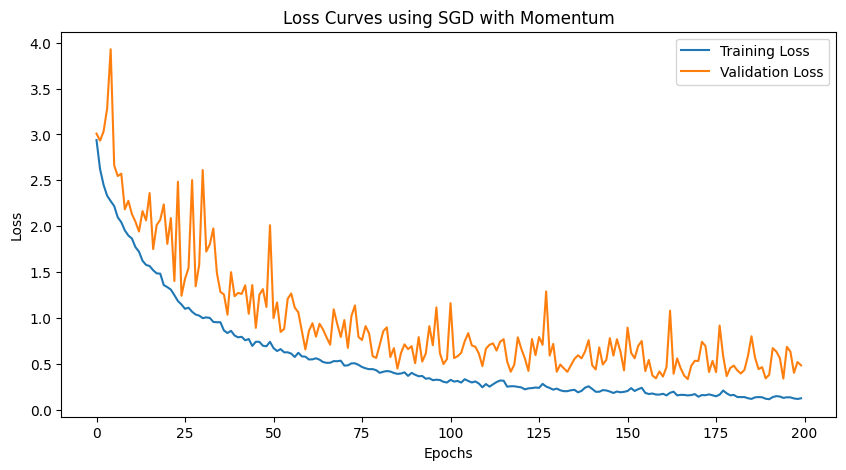

In [4]:
# Replace Adam optimizer with SGD with momentum
cnn_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

# Train Model
epochs = 200
history = cnn_model.fit(train_data, validation_data=test_data, epochs=epochs, verbose=1)

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves using SGD with Momentum')
plt.legend()
plt.show()

## Using Adadelta Optimizer and Plotting weights and biases

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.2406 - loss: 2.5689 - val_accuracy: 0.2476 - val_loss: 2.9365
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.2811 - loss: 2.4086 - val_accuracy: 0.1833 - val_loss: 2.9052
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.2767 - loss: 2.3437 - val_accuracy: 0.1762 - val_loss: 2.8607
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.3061 - loss: 2.2448 - val_accuracy: 0.2571 - val_loss: 2.8111
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.3422 - loss: 2.1433 - val_accuracy: 0.2524 - val_loss: 2.7662
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.3139 - loss: 2.1291 - val_accuracy: 0.2857 - val_loss: 2.6971
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.3391 - loss: 2.0498 - val_accuracy: 0.2643 - val_loss: 2.6845
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.3659 - loss: 2.0268 - val_accuracy: 0.2381 - v

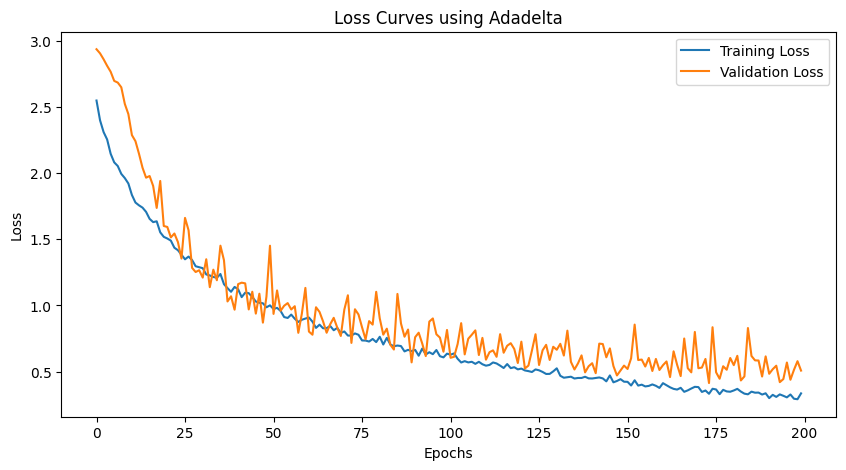

In [5]:
import matplotlib.pyplot as plt

# Replace Adam optimizer with Adadelta
cnn_model.compile(optimizer=tf.keras.optimizers.Adadelta(learning_rate=0.1),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

# Train Model
epochs = 200
history = cnn_model.fit(train_data, validation_data=val_data, epochs=epochs, verbose=1)

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves using Adadelta')
plt.legend()
plt.show()

## Using Adam Optimizer and Plotting weights and biases

/home/anupam/miniconda3/envs/myenv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 182s 8s/step - accuracy: 0.1287 - loss: 2.9625 - val_accuracy: 0.1095 - val_loss: 2.9721
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.2021 - loss: 2.6338 - val_accuracy: 0.0857 - val_loss: 2.9133
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.2690 - loss: 2.3555 - val_accuracy: 0.0905 - val_loss: 2.8595
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.2918 - loss: 2.2259 - val_accuracy: 0.1881 - val_loss: 2.7721
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.3500 - loss: 2.1013 - val_accuracy: 0.3238 - val_loss: 2.6416
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.3866 - loss: 1.9754 - val_accuracy: 0.2667 - val_loss: 2.5562
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.4134 - loss: 1.8961 - val_accuracy: 0.4143 - val_loss: 2.4264
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.4398 - loss: 1.8071 - val_accuracy: 0.3976 - 

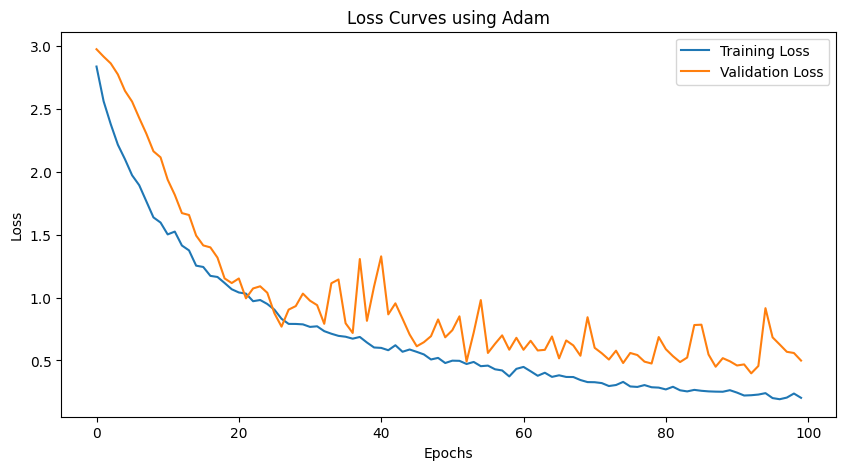

In [4]:
import matplotlib.pyplot as plt

# Replace optimizer with Adam
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

# Train Model
epochs = 100
history = cnn_model.fit(train_data, validation_data=val_data, epochs=epochs, verbose=1)

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves using Adam')
plt.legend()
plt.show()

## Using Adagrad Optimizer and Plotting Weights and Biases

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.4028 - loss: 2.2344 - val_accuracy: 0.5143 - val_loss: 1.7135
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.7437 - loss: 0.8281 - val_accuracy: 0.6905 - val_loss: 0.8817
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.8199 - loss: 0.5198 - val_accuracy: 0.7405 - val_loss: 0.9185
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.8683 - loss: 0.4228 - val_accuracy: 0.8452 - val_loss: 0.4380
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.9080 - loss: 0.2942 - val_accuracy: 0.8500 - val_loss: 0.4839
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.9216 - loss: 0.2437 - val_accuracy: 0.8548 - val_loss: 0.5369
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.9221 - loss: 0.2703 - val_accuracy: 0.8690 - val_loss: 0.4053
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.9351 - loss: 0.2186 - val_accuracy: 0.8500 - v

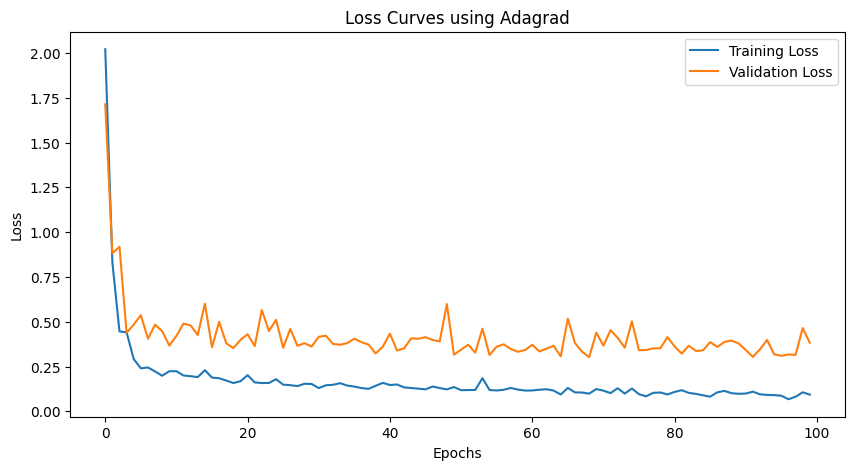

In [5]:
import matplotlib.pyplot as plt

# Replace optimizer with Adagrad
cnn_model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.01),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

# Train Model
epochs = 100
history = cnn_model.fit(train_data, validation_data=val_data, epochs=epochs, verbose=1)

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves using Adagrad')
plt.legend()
plt.show()